In [1]:
import pandas as pd

In [2]:
data = pd.read_csv(r'D:\Coding\sentiment_api\data\processed\test.csv')
print('This is the information about the dataset: ')
print(data.info())
print('This is the description of the dataset: ')
print(data.describe())
print('This is the number of null values in the dataset: ')
print(data.isnull().sum())
print('These are the columns in the dataset: ')
print(data.columns)
print('This is the shape of the dataset: ')
print(data.shape)
print('This is the size of the dataset: ')
print(data.size)
print('These are the first 5 rows of the dataset: ')
print(data.head())
print()

This is the information about the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1443 entries, 0 to 1442
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      1443 non-null   int64  
 1   sentiment                     1443 non-null   object 
 2   airline_sentiment_confidence  1443 non-null   float64
 3   negativereason                908 non-null    object 
 4   airline                       1443 non-null   object 
 5   text                          1443 non-null   object 
 6   tweet_created                 1443 non-null   object 
 7   retweet_count                 1443 non-null   int64  
 8   char_len                      1443 non-null   int64  
 9   word_count                    1443 non-null   int64  
 10  date                          1443 non-null   object 
 11  hour                          1443 non-null   int64  
 12  label_int         

In [3]:
data.drop_duplicates()
data.drop(columns='tweet_id', inplace=True)

In [4]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

categorical_cols = data.select_dtypes(include=['object','category']).columns.tolist()

for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col].astype(str))


print('This is the information about the dataset: ')
print(data.info())
print('This is the description of the dataset: ')
print(data.describe())
print('This is the number of null values in the dataset: ')
print(data.isnull().sum())
print('These are the columns in the dataset: ')
print(data.columns)
print('This is the shape of the dataset: ')
print(data.shape)
print('This is the size of the dataset: ')
print(data.size)
print('These are the first 5 rows of the dataset: ')
print(data.head())
print()

This is the information about the dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1443 entries, 0 to 1442
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   sentiment                     1443 non-null   int64  
 1   airline_sentiment_confidence  1443 non-null   float64
 2   negativereason                1443 non-null   int64  
 3   airline                       1443 non-null   int64  
 4   text                          1443 non-null   int64  
 5   tweet_created                 1443 non-null   int64  
 6   retweet_count                 1443 non-null   int64  
 7   char_len                      1443 non-null   int64  
 8   word_count                    1443 non-null   int64  
 9   date                          1443 non-null   int64  
 10  hour                          1443 non-null   int64  
 11  label_int                     1443 non-null   int64  
dtypes: float64(1), int

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numerical_cols = data.select_dtypes(include=['int64','float64']).columns.tolist()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])
print(data[numerical_cols])


      sentiment  airline_sentiment_confidence  negativereason   airline  \
0      1.953749                     -3.357143        1.053136 -0.164519   
1      0.625163                      0.607178        1.053136 -0.164519   
2     -0.703423                      0.607178       -0.895879  1.147091   
3     -0.703423                      0.607178       -1.452741  0.491286   
4      1.953749                      0.607178        1.053136 -0.820325   
...         ...                           ...             ...       ...   
1438   1.953749                     -1.505052        1.053136 -0.164519   
1439  -0.703423                      0.607178       -0.895879 -1.476130   
1440  -0.703423                      0.607178       -1.452741  0.491286   
1441  -0.703423                      0.607178       -1.174310  0.491286   
1442   0.625163                     -1.455264        1.053136 -0.820325   

          text  tweet_created  retweet_count  char_len  word_count      date  \
0    -0.410507     

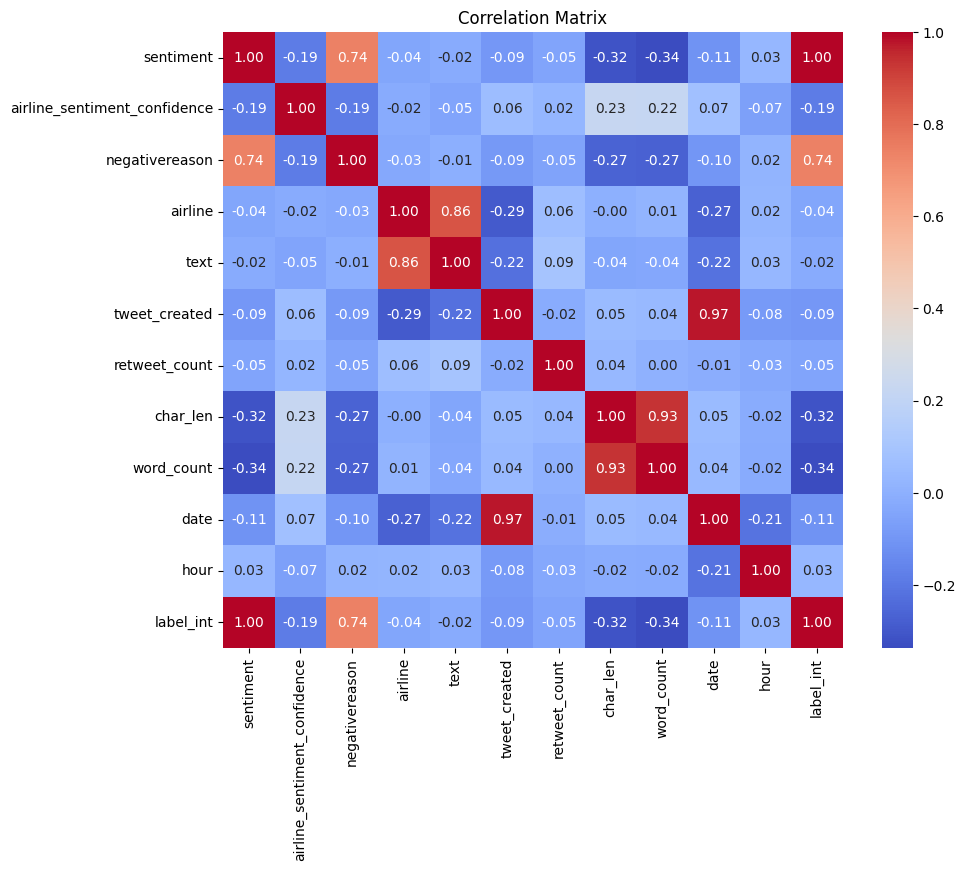

In [6]:
corr = data.corr()
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [7]:
# data.to_csv(r'D:\Coding\sentiment_api\data\processed\test_1.csv', index=False)